In [1]:
from scipy import linalg as la
import numpy as np 
from modules import model_BHZ_2D as bhz
import kwant
import matplotlib.pyplot as plt
from importlib import reload
from modules import functions as fn
from modules import plotting as pl
import pickle as pi
from pathlib import Path
import os,re


# model

In [7]:
reload(bhz)
p = bhz.params
L  = 10
p['A'] = 1
p['B'] = 1
p['Delta'] = 2
# p['dis_hadamard'] = 50
sys,_ = bhz.system_2D_BHZ(p=p,Lx=L,Ly=L,finalize=True)
# ham = sys.finalized().hamiltonian_submatrix()
ham = sys.hamiltonian_submatrix()


In [33]:
print([(site.tag,i) for i,site in enumerate(sys.sites)])

[(array([-1, -1]), 0), (array([-1, 0]), 1), (array([0, -1]), 2), (array([0, 0]), 3)]


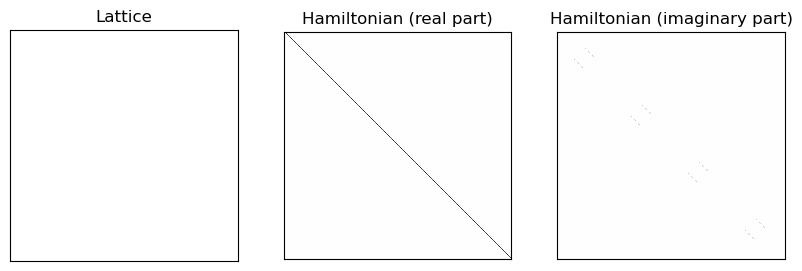

In [33]:

#### plotting ####
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[1].matshow(
    ham.real,
    cmap="bwr",
    clim=(-np.max(np.abs(ham.real)), np.max(np.abs(ham.real))),
)
ax[2].matshow(
    ham.imag,
    cmap="bwr",
    clim=(-np.max(np.abs(ham.real)), np.max(np.abs(ham.real))),
)

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

ax[0].set_title("Lattice")
ax[1].set_title("Hamiltonian (real part)")
ax[2].set_title("Hamiltonian (imaginary part)")

plt.show()

Text(0.5, 1.0, 'Energy Spectrum')

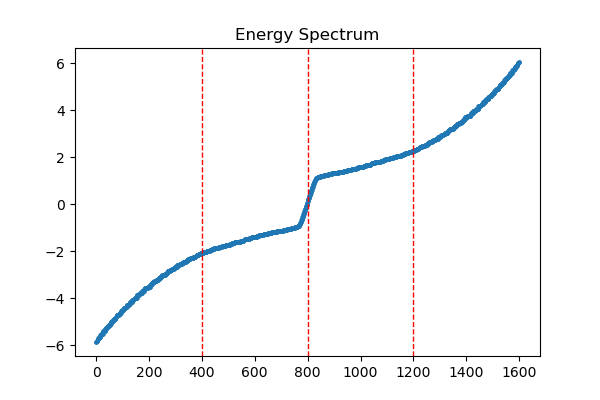

In [36]:
%matplotlib widget

from scipy import linalg as la

e, v = la.eigh(ham)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(range(len(e)), e, s=5)
ax.axvline(len(e) // 4, color="red", ls="--", linewidth=1)
ax.axvline(len(e) // 2, color="red", ls="--", linewidth=1)
ax.axvline(3 * len(e) // 4, color="red", ls="--", linewidth=1)
ax.set_title("Energy Spectrum")

# localizer

In [43]:



reload(bhz)
p = bhz.params
p['Lx'] = 10
p['Ly'] = 10
p['A'] = 1
p['B'] = 1
p['Delta'] =0.5


sys = bhz.system_2D_BHZ(p)
fsys = sys.finalized()


In [44]:
TR = bhz.TR_op(len(fsys.sites))


In [30]:
reload(fn)
pfaf, pfaf_list = fn.spectral_localizer_AII2D(syst=sys,W=0,E0=0,TR=TR)

E0: 0 x0,y0: -0.5 -0.5 kappa: 0.1 W: 0
Averaging over realizations...
Percent: [####################] 100% Done...
Realization Pfaffian: -1.0
Pfaffian sign: -1.0


In [ ]:


reload(fn)
reload(bhz)
p = bhz.params
p['Lx'] = 10
p['Ly'] = 10
p['A'] = 1
p['B'] = 1
p['Delta'] = 2

kappa_range = np.linspace(0,1.5,50)
E_range = np.linspace(-2.5,2.5,50)
sys,_ = bhz.system_2D_BHZ(Lx=10,Ly=10,params=p)
fsys = sys.finalized()
TR = bhz.TR_op(len(fsys.sites))
p_spec = fn.params.copy()


E_kap_dict_reals = {}

locgap_matrix = np.zeros((len(E_range),len(kappa_range)))

for i, E in enumerate(E_range):   

    E_kap_dict_reals[E] = []

    for j, kap in enumerate(kappa_range):
        p_spec['kappa'] = kap
        locgap, locgap_list = fn.spectral_localizer_AII2D(syst=sys,W=0,E0=E,TR=TR,compute_inv=False,compute_localgap=True,p=p_spec)
        locgap_matrix[i,j] = locgap
        E_kap_dict_reals[E].append(locgap_list)

E0: 0 x0,y0: -0.5 -0.5 kappa: 0.0 W: 0
Averaging over realizations...
Percent: [####################] 100% Done...
Local gap realization: [-0.03579746]
Time: 0.38398338299884927
Local gap: 0.03579746345796332
E0: 0 x0,y0: -0.5 -0.5 kappa: 0.030612244897959183 W: 0
Averaging over realizations...
Percent: [####################] 100% Done...
Local gap realization: [0.27440925]
Time: 0.37519453399727354
Local gap: 0.2744092477564166
E0: 0 x0,y0: -0.5 -0.5 kappa: 0.061224489795918366 W: 0
Averaging over realizations...
Percent: [####################] 100% Done...
Local gap realization: [-0.552461]
Time: 0.3926647699991008
Local gap: 0.552460997391515
E0: 0 x0,y0: -0.5 -0.5 kappa: 0.09183673469387754 W: 0
Averaging over realizations...
Percent: [####################] 100% Done...
Local gap realization: [-0.824284]
Time: 0.38315208700078074
Local gap: 0.8242840022824457
E0: 0 x0,y0: -0.5 -0.5 kappa: 0.12244897959183673 W: 0
Averaging over realizations...
Percent: [####################] 100% D

KeyboardInterrupt: 

In [72]:
locgap_matrix = np.zeros((len(E_range),len(kappa_range)))

for i,E in enumerate(E_range):
    elem = [elems[0] for elems in  E_kap_dict[E]]
    locgap_matrix[i,:] = elem

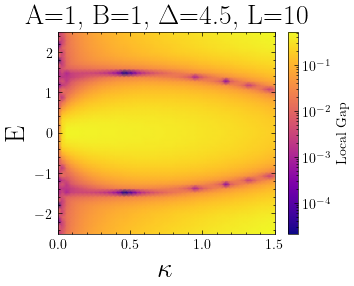

In [86]:
reload(pl)
locgap_matrix = pi.load(open('/Users/laura/Desktop/TAI-localizer/codes/data/bubble/bubble_kappa_0.0_1.5)_E_-2.5_2.5_L_10_A1_B1_Delta_4.5','rb'))
E_range = np.linspace(-2.5,2.5,50)

pl.map_kappaE_locgap(kappa_range,E_range,np.abs(locgap_matrix),title=r'A=1, B=1, $\Delta$=4.5, L=10')

## phase diagram

In [3]:

folder =  Path.cwd() / "data"/"hadamard"/"locgap-phase"  /"locgap" 


g = []
def extract_E_value(filename):
    match = re.search(r'_Delta_([-+]?[0-9]*\.?[0-9]+)', filename)
    if match:
        return float(match.group(1))
    return float('inf')  # Por si no encuentra el valor

print(sorted(os.listdir(folder), key=extract_E_value))

for file in sorted(os.listdir(folder), key=extract_E_value):
    g.append(pi.load(open(os.path.join(folder, file), 'rb')))



['locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-2.0', 'locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-1.8775510204081634', 'locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-1.7551020408163265', 'locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-1.6326530612244898', 'locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-1.510204081632653', 'locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-1.3877551020408163', 'locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-1.2653061224489797', 'locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-1.1428571428571428', 'locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-1.0204081632653061', 'locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-0.8979591836734695', 'locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-0.7755102040816326', 'locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-0.653061224489796', 'locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-0.5306122448979593', 'locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-0.40816326530612246', 'locgap_kappa_0.1_W_0.0_12.0_L_10_A1_B1_Delta_-0.28571428571428

In [5]:

D_completed = [list(elem.keys())[0] for elem in g]
g_completed = [np.array(list(elem.values()))[0] for elem in g]

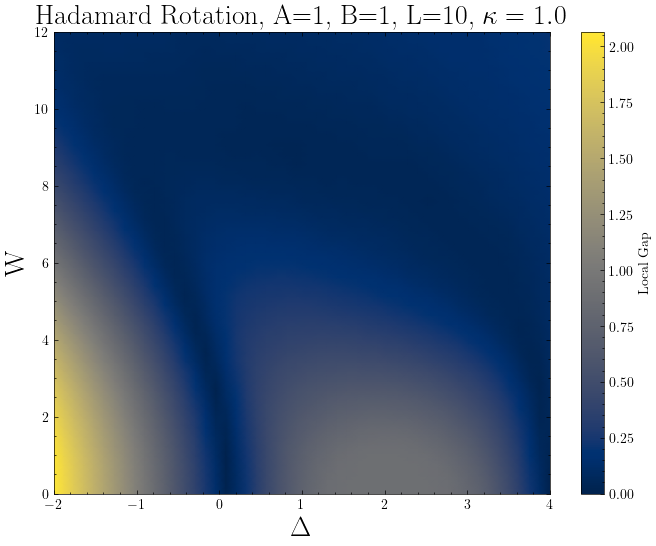

In [7]:
reload(pl)
pl.map_Delta_W_localgap(D_completed,np.linspace(0,12,50),np.array(g_completed)[:,:,0].T,title=r'Hadamard Rotation, A=1, B=1, L=10, $\kappa=1.0$')

# conductance

Hadamard Rotation


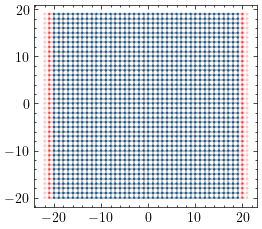

In [118]:
reload(bhz)
p = bhz.params

p['A'] = 1
p['B'] = 1
p['Delta'] = 2
p['W'] = 0
p['mu_leads'] = 0
p['hadamard'] = True

syst,leadp,leadm = bhz.BHZ_with_leads(Lx=20,Ly=20,params=p)


kwant.plot(syst);

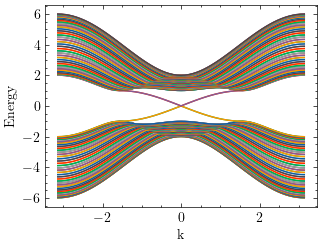

In [119]:
kwant.plotter.bands(leadp);

In [115]:
import kwant 

kwant_op = kwant.operator.Density(syst, sum=False)
local_dos = kwant.kpm.SpectralDensity(syst, operator = kwant_op,num_moments=300,rng=0)



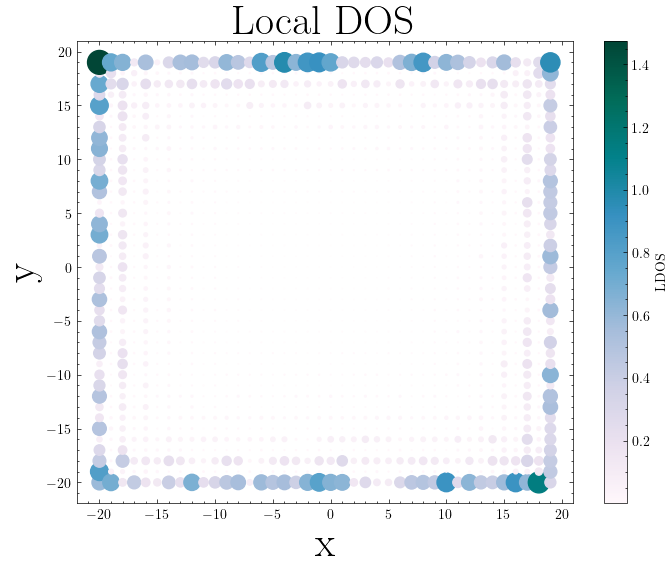

In [116]:
sites = np.array([site.pos for site in syst.sites])
# Compute the local density of states at zero energy
ldos_real_space = np.abs(local_dos(0.1)).real

plt.figure(figsize=(8,6))
# plt.scatter(sites[:, 0], sites[:, 1], color='black',sizes=1)
# plt.scatter(sites[:, 0], sites[:, 1], color='black',s=0.1)

plt.scatter(sites[:, 0], sites[:, 1], c=ldos_real_space, cmap='PuBuGn', sizes=200*ldos_real_space)


plt.colorbar(label='LDOS')
plt.title(r'Local DOS',fontsize=30)
plt.xlabel('x',fontsize=30)
plt.ylabel('y',fontsize=30)
plt.show()

In [121]:
reload(fn)
reload(bhz)
p = bhz.params

p['A'] = 1
p['B'] = 1
p['Delta'] = 2
p['W'] = 0
p['mu_leads'] = 1.9
p['hadamard'] = True

fn.average_conductance_W(0.01,Wr=[0],Lx=10,Ly=10,params=p)

Averaging over realizations...
Percent: [####################] 100% Done...
Hadamard Rotation
W: 0 G: 1.9999999626769867


([1.9999999626769867], [[1.9999999626769867]])

## phase diagram

In [129]:

folder =  Path.cwd() / "data"/"hadamard"/"conductance"  / "g" 


g = []
def extract_E_value(filename):
    match = re.search(r'_Delta_([-+]?[0-9]*\.?[0-9]+)', filename)
    if match:
        return float(match.group(1))
    return float('inf')  # Por si no encuentra el valor

print(sorted(os.listdir(folder), key=extract_E_value))

for file in sorted(os.listdir(folder), key=extract_E_value):
    g.append(pi.load(open(os.path.join(folder, file), 'rb')))



['G_W_0.0_12.0_L_10_A1_B1_Delta_-2.0', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-1.8775510204081634', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-1.7551020408163265', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-1.6326530612244898', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-1.510204081632653', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-1.3877551020408163', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-1.2653061224489797', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-1.1428571428571428', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-1.0204081632653061', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-0.8979591836734695', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-0.7755102040816326', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-0.653061224489796', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-0.5306122448979593', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-0.40816326530612246', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-0.2857142857142858', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-0.16326530612244894', 'G_W_0.0_12.0_L_10_A1_B1_Delta_-0.04081632653061229', 'G_W_0.0_12.0_L_10_A1_B1_Delta_0.08163265306122458', 'G_W_0.0_12.0_L_10_A1_B1_Delta_0.204081632653061', 'G_W_0.0

In [130]:

D_completed = [list(elem.keys())[0] for elem in g]
g_completed = [list(elem.values())[0] for elem in g]

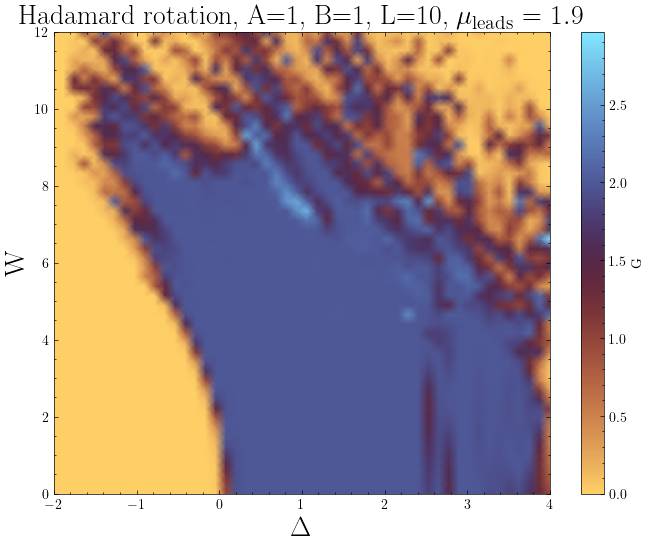

In [132]:
reload(pl)
pl.map_Delta_W_conductance(D_completed,np.linspace(0,12,50),np.array(g_completed).T,title=r'Hadamard rotation, A=1, B=1, L=10, $\mu_{\text{leads}}=1.9$')

In [90]:

import numpy as np

b=np.linspace(-2,4,50)

E = len(b)
# for elem in b:
#     if elem not in a:
#         b.remove(elem)
# # print(b)
W = []
for i,elem in enumerate(b):
    # print(elem)
    if np.mod(i+1,E)==0:
        print('\n')
        lista = list(b[(i+1)-E:i+1])
        print(" ".join(f'{x}' for x in lista) )
        a = " ".join(f'"{[x]}"' for x in lista)
        W.append(a)



-2.0 -1.8775510204081634 -1.7551020408163265 -1.6326530612244898 -1.510204081632653 -1.3877551020408163 -1.2653061224489797 -1.1428571428571428 -1.0204081632653061 -0.8979591836734695 -0.7755102040816326 -0.653061224489796 -0.5306122448979593 -0.40816326530612246 -0.2857142857142858 -0.16326530612244894 -0.04081632653061229 0.08163265306122458 0.204081632653061 0.3265306122448979 0.44897959183673475 0.5714285714285712 0.693877551020408 0.8163265306122449 0.9387755102040813 1.0612244897959182 1.183673469387755 1.306122448979592 1.4285714285714284 1.5510204081632653 1.6734693877551021 1.7959183673469385 1.9183673469387754 2.040816326530612 2.163265306122449 2.2857142857142856 2.408163265306122 2.5306122448979593 2.6530612244897958 2.775510204081632 2.8979591836734695 3.020408163265306 3.1428571428571423 3.2653061224489797 3.387755102040816 3.5102040816326525 3.63265306122449 3.7551020408163263 3.8775510204081627 4.0


# plots

In [11]:

folder =  Path.cwd() / "data"/"spin_disorder" /"z2_vs_Delta_prob75" / "z2" 


dic = []
def extract_E_value(filename):
    match = re.search(r'_Delta_([-+]?[0-9]*\.?[0-9]+)', filename)
    if match:
        return float(match.group(1))
    return float('inf')  # Por si no encuentra el valor

print(sorted(os.listdir(folder), key=extract_E_value))

for file in sorted(os.listdir(folder), key=extract_E_value):
    dic.append(pi.load(open(os.path.join(folder, file), 'rb')))


# folder =  Path.cwd() / "data"/"kappachecks_Delta2_W" /"z2" / "kappa_0.5" / "z2" 


# dic2 = []
# def extract_E_value(filename):
#     match = re.search(r'_Delta_([-+]?[0-9]*\.?[0-9]+)', filename)
#     if match:
#         return float(match.group(1))
#     return float('inf')  # Por si no encuentra el valor

# print(sorted(os.listdir(folder), key=extract_E_value))

# for file in sorted(os.listdir(folder), key=extract_E_value):
#     dic2.append(pi.load(open(os.path.join(folder, file), 'rb')))



# folder =  Path.cwd() / "data"/"kappachecks_Delta2_W" /"z2" / "kappa_1.0" / "z2" 


# dic3 = []
# def extract_E_value(filename):
#     match = re.search(r'_Delta_([-+]?[0-9]*\.?[0-9]+)', filename)
#     if match:
#         return float(match.group(1))
#     return float('inf')  # Por si no encuentra el valor

# print(sorted(os.listdir(folder), key=extract_E_value))

# for file in sorted(os.listdir(folder), key=extract_E_value):
#     dic3.append(pi.load(open(os.path.join(folder, file), 'rb')))

# folder =  Path.cwd() / "data"/"conductance" /"phase-diag" / "g" 
# g= pi.load(open(folder/'G_W_0.0_12.0_L_5_A1_B1_Delta_2.040816326530612','rb'))

['reals_kappa_0.1_dishadamard_75_L_10_A1_B1_Delta_-2.0', 'reals_kappa_0.1_dishadamard_75_L_10_A1_B1_Delta_-1.8775510204081634', 'reals_kappa_0.1_dishadamard_75_L_10_A1_B1_Delta_-1.7551020408163265', 'reals_kappa_0.1_dishadamard_75_L_10_A1_B1_Delta_-1.6326530612244898', 'reals_kappa_0.1_dishadamard_75_L_10_A1_B1_Delta_-1.510204081632653', 'reals_kappa_0.1_dishadamard_75_L_10_A1_B1_Delta_-1.3877551020408163', 'reals_kappa_0.1_dishadamard_75_L_10_A1_B1_Delta_-1.2653061224489797', 'reals_kappa_0.1_dishadamard_75_L_10_A1_B1_Delta_-1.1428571428571428', 'reals_kappa_0.1_dishadamard_75_L_10_A1_B1_Delta_-1.0204081632653061', 'reals_kappa_0.1_dishadamard_75_L_10_A1_B1_Delta_-0.8979591836734695', 'reals_kappa_0.1_dishadamard_75_L_10_A1_B1_Delta_-0.7755102040816326', 'reals_kappa_0.1_dishadamard_75_L_10_A1_B1_Delta_-0.653061224489796', 'reals_kappa_0.1_dishadamard_75_L_10_A1_B1_Delta_-0.5306122448979593', 'reals_kappa_0.1_dishadamard_75_L_10_A1_B1_Delta_-0.40816326530612246', 'reals_kappa_0.1_dish

In [12]:

W_completed = [list(elem.keys())[0] for elem in dic]
y_completed = [list(elem.values())[0] for elem in dic]


# W_completed2 = [list(elem.keys())[0] for elem in dic2]
# y_completed2 = [list(elem.values())[0] for elem in dic2]


# W_completed3 = [list(elem.keys())[0] for elem in dic3]
# y_completed3 = [list(elem.values())[0] for elem in dic3]




C:\Users\Laura\AppData\Local\Temp\ipykernel_27628\1790584734.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


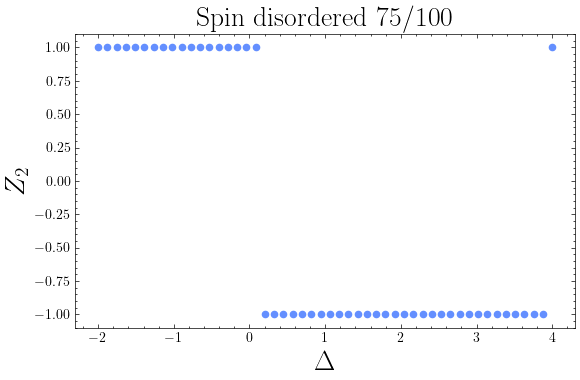

In [14]:
%matplotlib widget
C = ['#648FFF','#DC267F', '#FE6100','#785EF0','#FFB000']

plt.style.use('science')
fig,ax = plt.subplots(figsize=(6,4))
Wc = 8
nu = 2.6
ax.scatter(np.array(W_completed), y_completed,marker='o',c=C[0],s=20)

# ax.scatter(np.abs(np.array(W_completed)-Wc)/(0.1**(1/nu)), y_completed,marker='o',c=C[0],label='kappa=0.1',s=20)
# ax.scatter(np.abs(np.array(W_completed2)-Wc)/(0.5**(1/nu)), y_completed2,marker='o',c=C[1],label='kappa=0.5',s=20)
# ax.scatter(np.abs(np.array(W_completed3)-Wc)/(1.0**(1/nu)), y_completed3,marker='o',c=C[2],label='kappa=1.0',s=20)
# ax2= ax.twinx()
# ax2.plot(np.linspace(0,12,50), list(g.values())[0],linestyle='--',c='black',label='conductance')

ax.legend()
# ax2.legend()
# ax.set_title(f'Wc = {Wc}, nu = {nu}')
ax.set_title(f'Spin disordered 75/100 ',fontsize=20)
ax.set_xlabel(r'$\Delta$',fontsize=20)

# ax.set_xlabel(r'$\frac{|W-Wc|}{\kappa^{1/\nu}}$',fontsize=20)
ax.set_ylabel(r'$Z_2$',fontsize=20)
# ax2.set_ylabel('g',fontsize=20)
plt.tight_layout()




# rotarion

In [96]:
hadamard = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]])

print(hadamard@ bhz.sigma_x@hadamard.conj().T)
print(hadamard@ bhz.sigma_y@hadamard.conj().T)
print(hadamard@ bhz.sigma_z@hadamard.conj().T)

[[ 1.  0.]
 [ 0. -1.]]
[[0.+0.j 0.+1.j]
 [0.-1.j 0.+0.j]]
[[0. 1.]
 [1. 0.]]


hadamard rotation converts:

sigma_x -> sigma_z

sigma_y -> -sigma_y

sigma_z -> sigma_x

In [58]:
import numpy as np

M = 20        # probabilidad de sacar un 1, en porcentaje
lista = []

rng = np.random.default_rng(0)
for j in range(100):
      # opcional

    numero = rng.choice([0, 1], p=[1 - M/100, M/100])
    lista.append(numero)
print(len(np.where(np.array(lista)==1)[0])
)


27


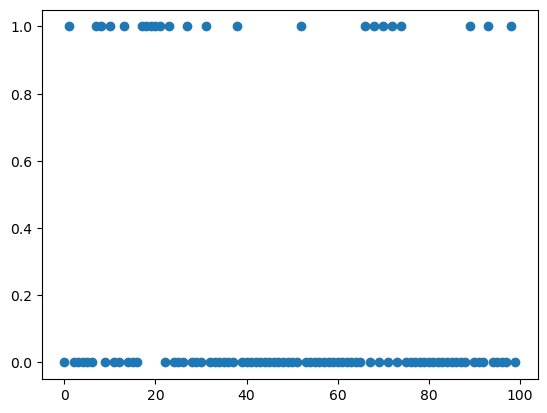

In [5]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(range(100),lista)